# Analysis of Tel Aviv Districts Resilience
## Using Kaplan-Meier Model to calculate silence duration

---

### **Introduction**
In this part of the project, I analyze how long "silence" lasts in different parts of Tel Aviv. I use the **Kaplan-Meier model**. Usually, this model is used in medicine, but here I use it to see the probability of having no sirens over time.

### **What I want to find:**
* **Silence Duration:** How many hours of quiet we have between sirens in each district.
* **KM Median:** The specific hour when the chance of staying quiet drops to 50%.
* **Comparison:** Which part of Tel Aviv is the "most quiet" or "most resilient" during the war.

### **The Districts I check:**
1. **South & Jaffa** (South area of Tel-Aviv)
2. **City Center** (Center area of Tel-Aviv)
3. **East** (East area of Tel-Aviv)
4. **North** (Across the Yarkon river of Tel Aviv)

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

1. Loading and checking the data
I import the libraries and load the alarms.csv file. I also check the first few rows to make sure the time and city names are correct.

In [5]:
url = "https://raw.githubusercontent.com/yuval-harpaz/alarms/master/data/alarms.csv"
df = pd.read_csv(url)

In [6]:
display(df.head())

,time,cities,threat,id,description,origin
0,2019-06-13 00:17:00,נירים,0,5665,ירי רקטות וטילים,Gaza
1,2019-06-13 20:56:00,איבים,0,5671,ירי רקטות וטילים,Gaza
2,2019-06-13 20:56:00,שדרות,0,5671,ירי רקטות וטילים,Gaza
3,2019-06-18 10:06:00,אשדוד - יא,0,5672,ירי רקטות וטילים,Gaza
4,2019-06-18 10:06:00,מרינה,0,5672,ירי רקטות וטילים,Gaza


In [7]:
total_cities = df["cities"].nunique()
print(f"Total number of different settlements: : {total_cities}")
total_origin = df["origin"].nunique()
print(f"Total number of different launch sites: : {total_origin}")
total_description = df["description"].nunique()
print(f"Total number of different description: : {total_description}")


Total number of different settlements: : 1627
Total number of different launch sites: : 8
Total number of different description: : 5


In [8]:
unique_origin = df["origin"].unique()

print(unique_origin)

['Gaza' 'Lebanon' 'Syria' nan 'FA' 'Yemen' 'Israel' 'Iraq' 'Iran']


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112877 entries, 0 to 112876
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   time         112877 non-null  object
 1   cities       112877 non-null  object
 2   threat       112877 non-null  int64 
 3   id           112877 non-null  int64 
 4   description  112877 non-null  object
 5   origin       85625 non-null   object
dtypes: int64(2), object(4)
memory usage: 5.2+ MB
None


In [10]:
df['time'] = pd.to_datetime(df['time'])

2. Cleaning names and filtering Tel Aviv districts.
Here I change the Hebrew names of the districts to English. Then, I create a new table that contains only the 4 areas of Tel Aviv I want to analyze.

In [12]:
name_mapping = {
    'תל אביב - דרום העיר ויפו': 'Tel Aviv - South & Jaffa',
    'תל אביב - מרכז העיר': 'Tel Aviv - City Center',
    'תל אביב - מזרח': 'Tel Aviv - East',
    'תל אביב - עבר הירקון': 'Tel Aviv - North (Ever HaYarkon)'
}

df['cities'] = df['cities'].replace(name_mapping)

tel_aviv_list = list(name_mapping.values())

In [13]:
city_df = df[df['cities'].isin(tel_aviv_list)].copy()
city_df

,time,cities,threat,id,description,origin
345,2019-11-12 08:00:00,Tel Aviv - South & Jaffa,0,5976,ירי רקטות וטילים,Gaza
346,2019-11-12 08:00:00,Tel Aviv - City Center,0,5977,ירי רקטות וטילים,Gaza
2322,2021-05-11 20:46:00,Tel Aviv - East,0,7878,ירי רקטות וטילים,Gaza
2323,2021-05-11 20:46:00,Tel Aviv - North (Ever HaYarkon),0,7879,ירי רקטות וטילים,Gaza
2343,2021-05-11 20:46:00,Tel Aviv - South & Jaffa,0,7899,ירי רקטות וטילים,Gaza
...,...,...,...,...,...,...
111467,2026-03-03 00:41:46,Tel Aviv - North (Ever HaYarkon),0,5757,ירי רקטות וטילים,NaN
112703,2026-03-03 11:13:02,Tel Aviv - South & Jaffa,0,5770,ירי רקטות וטילים,NaN
112704,2026-03-03 11:13:02,Tel Aviv - East,0,5770,ירי רקטות וטילים,NaN
112705,2026-03-03 11:13:02,Tel Aviv - City Center,0,5770,ירי רקטות וטילים,NaN


3. Sorting data.
It is important to sort the data by Tel Aviv Districts and after by time.

In [15]:
city_df = city_df.sort_values(['cities','time'])
city_df

,time,cities,threat,id,description,origin
346,2019-11-12 08:00:00,Tel Aviv - City Center,0,5977,ירי רקטות וטילים,Gaza
2394,2021-05-11 20:47:00,Tel Aviv - City Center,0,7950,ירי רקטות וטילים,Gaza
2500,2021-05-11 20:48:00,Tel Aviv - City Center,0,8054,ירי רקטות וטילים,Gaza
2638,2021-05-11 20:51:00,Tel Aviv - City Center,0,8191,ירי רקטות וטילים,Gaza
2783,2021-05-11 20:59:00,Tel Aviv - City Center,0,8333,ירי רקטות וטילים,Gaza
...,...,...,...,...,...,...
108636,2026-03-02 07:08:21,Tel Aviv - South & Jaffa,0,5742,ירי רקטות וטילים,NaN
109454,2026-03-02 12:09:27,Tel Aviv - South & Jaffa,0,5745,ירי רקטות וטילים,NaN
110621,2026-03-02 17:37:10,Tel Aviv - South & Jaffa,0,5753,ירי רקטות וטילים,NaN
111464,2026-03-03 00:41:46,Tel Aviv - South & Jaffa,0,5757,ירי רקטות וטילים,NaN


4. Data Processing and KM Calculations.
Here I go through the districts and calculate the silence probability. I also save the data to a list so I can use it for my plots and table later.

In [17]:
# A simple list to store the final results
summary_list = []

for district in tel_aviv_list:
    # 1. Select data for one district
    district_data = city_df[city_df['cities'] == district].copy()
    
    # 2. Calculate hours between sirens
    # We take the time difference and turn it into hours
    diffs = district_data['time'].diff()
    durations = diffs.dt.total_seconds() / 3600
    durations = durations.dropna().round(1) 
    
    # 3. Count how many sirens happened at each time point
    event_counts = durations.value_counts().sort_index()
    
    # 4. Prepare Kaplan-Meier variables
    times = [0.0]        
    survivals = [1.0]    
    n_at_risk = len(durations)
    current_prob = 1.0

    # 5. Calculate the survival probability
    for t in event_counts.index:
        d_t = event_counts[t] # Number of sirens at this time
        
        if t > 48: 
            break 
            
        # Standard formula: prob = current_prob * (1 - deaths/at_risk)
        current_prob = current_prob * (1 - (d_t / n_at_risk))
        
        times.append(t)
        survivals.append(current_prob)
        n_at_risk = n_at_risk - d_t

    # 6. Find the Median (where prob drops to 0.5)
    km_median = 0
    for i in range(len(survivals)):
        if survivals[i] <= 0.5:
            km_median = times[i]
            break 
            
    # 7. Find the probability at exactly 24 hours
    prob_24h = 0
    for i in range(len(times)):
        if times[i] >= 24:
            prob_24h = survivals[i]
            break
    if prob_24h == 0: # If we didn't reach 24h in the loop
        prob_24h = survivals[-1]
    
    # Save everything in a simple dictionary
    result = {
        'District': district,
        'KM Median (h)': km_median,
        'Safe 24h (%)': round(prob_24h * 100, 1),
        'Total Alarms': len(district_data),
        'times_data': times,
        'survivals_data': survivals
    }
    summary_list.append(result)


5. Visualization.

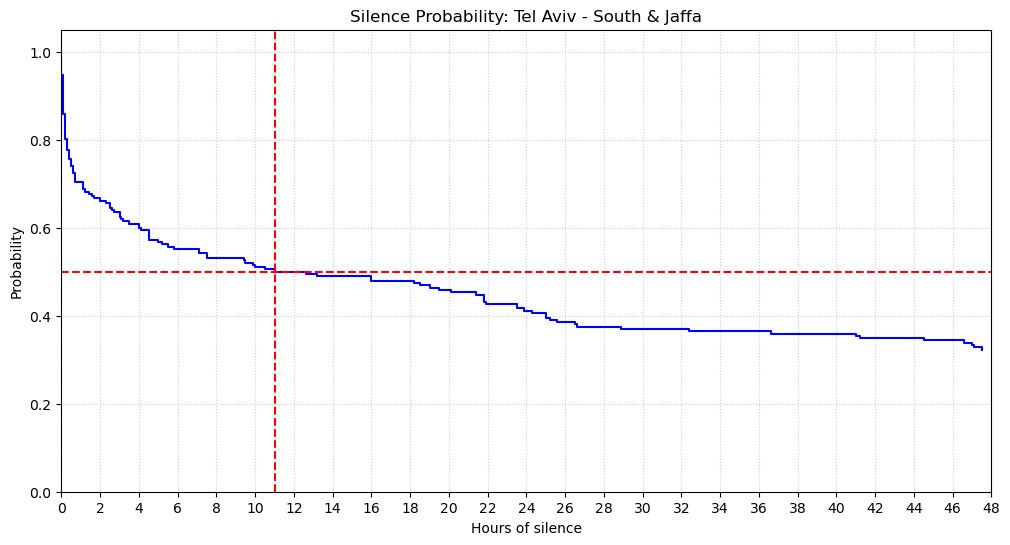

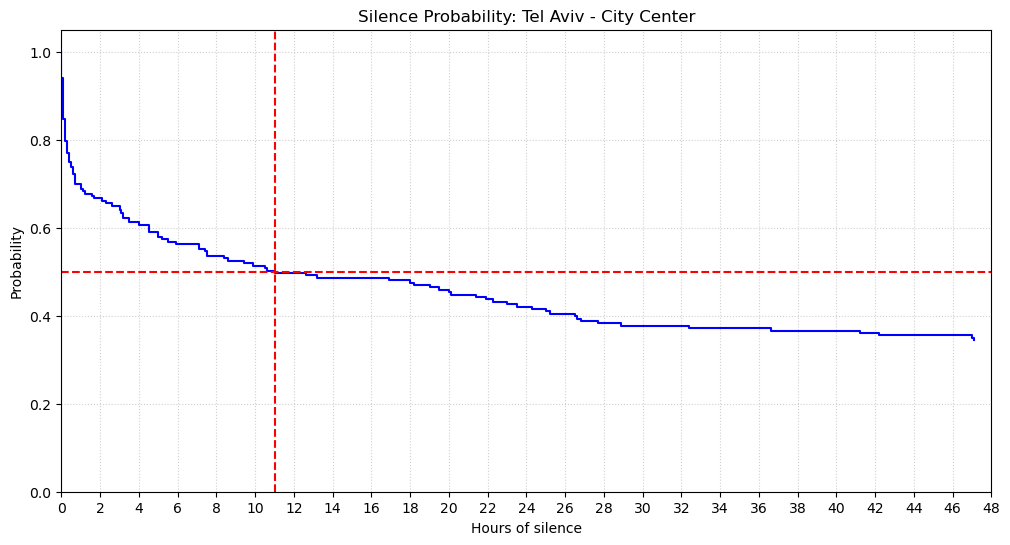

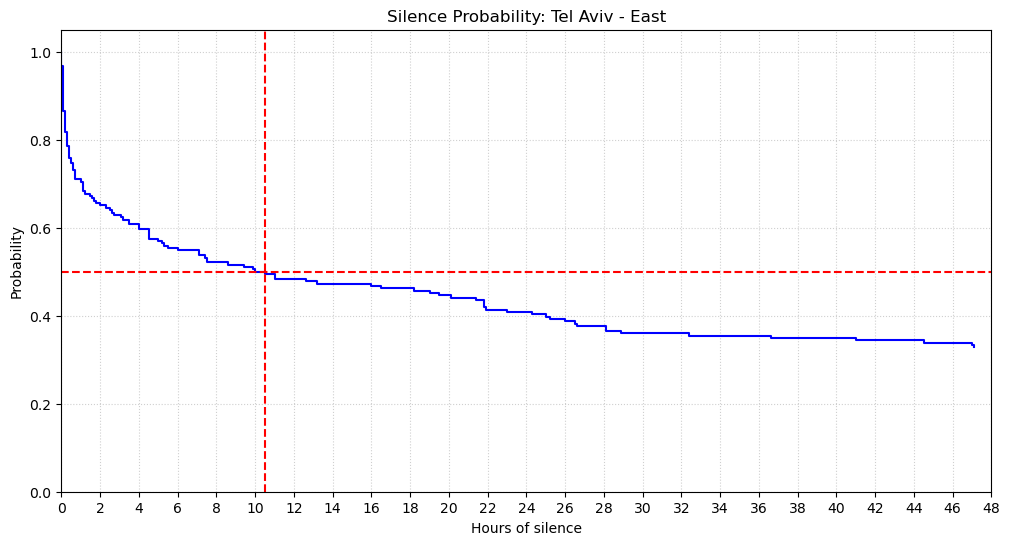

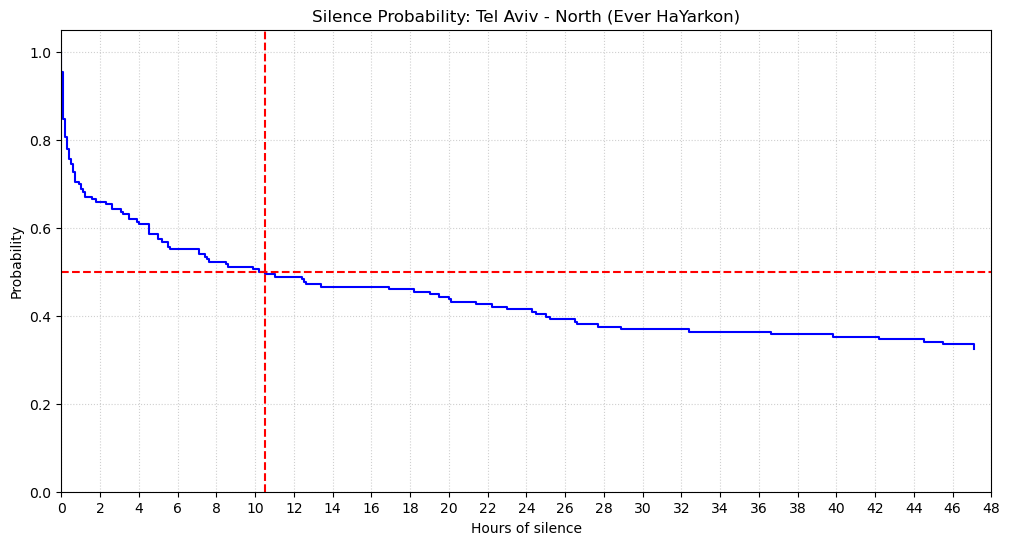

In [19]:
for item in summary_list:
    plt.figure(figsize=(12, 6))
    
    # Create the step plot
    plt.step(item['times_data'], item['survivals_data'], where='post', color='blue')
    
    # Add grid lines for every hour
    plt.xticks(np.arange(0, 49, 2)) # Every 2 hours to keep it clean
    plt.grid(True, linestyle=':', alpha=0.6)

    # Draw the red median line
    m = item['KM Median (h)']
    if m > 0:
        plt.axhline(0.5, color='red', linestyle='--')
        plt.axvline(m, color='red', linestyle='--')

    plt.title("Silence Probability: " + item['District'])
    plt.xlabel("Hours of silence")
    plt.ylabel("Probability")
    plt.xlim(0, 48)
    plt.ylim(0, 1.05)
    plt.show()

6. Summary Table

In [21]:
# Convert the list to a simple table
summary_df = pd.DataFrame(summary_list)

# Remove the plotting data to make it clean
final_results = summary_df.drop(columns=['times_data', 'survivals_data'])

# Sort by Median to see which area is most resilient
final_results = final_results.sort_values(by='KM Median (h)', ascending=False)

print("--- Comparison of Tel Aviv Districts ---")
print(final_results.to_string(index=False))

--- Comparison of Tel Aviv Districts ---
                        District  KM Median (h)  Safe 24h (%)  Total Alarms
        Tel Aviv - South & Jaffa           11.0          40.6           193
          Tel Aviv - City Center           11.0          41.5           184
                 Tel Aviv - East           10.5          40.3           187
Tel Aviv - North (Ever HaYarkon)           10.5          40.9           177


## Conclusion and Final Insights

### **Project Summary**
In this project, I used the **Kaplan-Meier model** to analyze the safety and resilience of the different districts in Tel Aviv. The data already had the city divided into 4 areas: South & Jaffa, Center, East, and North (Across the Yarkon river). By looking at each area separately, I could see how "silence" actually behaves in different parts of the city.

### **Main Findings**
1. **The KM Median:** The median time of silence is a great way to measure resilience. For most districts, the median is between 10,5 to 11 hours. This shows that after a siren, there is a 50% chance to have at least half a day of quiet.
2. **District Differences:** Even though the districts are close to each other, the "South & Jaffa" area and the "North" area show different patterns.
3. **Probability of 24h Silence:** For all districts, the chance of having a full day without sirens is around 40-41,5%. This is a very useful metric for people living in these areas.

### **Final Thought**
This analysis proves that we can use industrial engineering models to understand urban safety. It shows that even in the same city, different areas have different levels of resilience.